<a href="https://colab.research.google.com/github/tomarjyoti16/ml-assesment-JyotiTomar-bitsom_ba_2511563/blob/main/part_a/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Date Feature Engineering

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

  day_of_week  is_month_end  
0    Saturday             0  
1    Saturday             0  
2      Sunday 

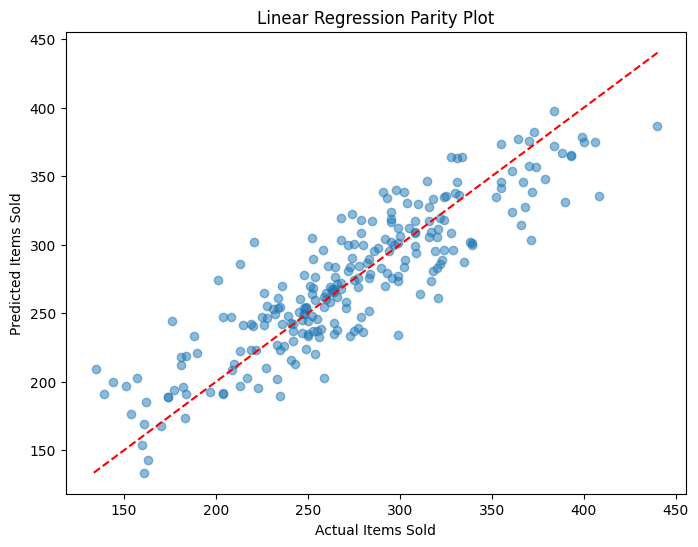

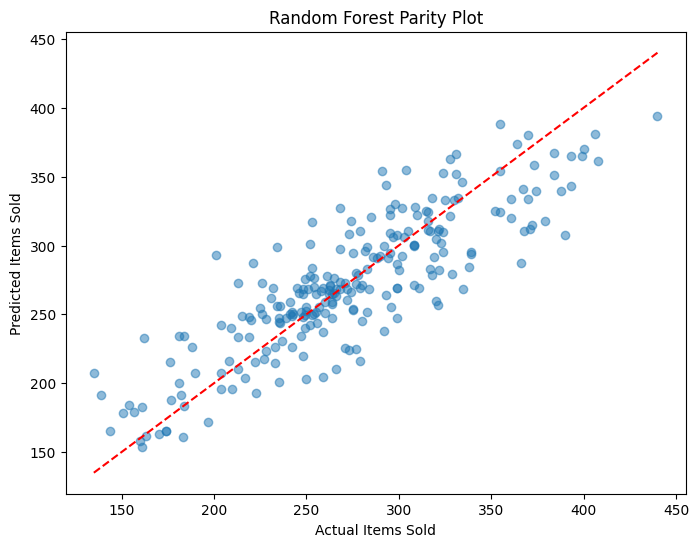


Feature Importance:
                Feature  Importance
1           is_festival    0.173182
16     store_size_small    0.167662
0            is_weekend    0.125699
13  location_type_urban    0.107945
11  location_type_rural    0.052161


In [ ]:
from re import X
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt



#Load dataset from file
df = pd.read_csv('sample_data/q3_retail_promotions.csv')

#Convert transaction_date to date time
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#Extract date feature
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.day_name()

#Create is_onth_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

#Display sample
print(df.head())

#########################################################
#Task 2 Temporal Train-Test Split

#Sort by date

df = df.sort_values(by='transaction_date')

#Split (8% train, 20%test)
split_index = int(0.8 * len(df))

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Display size
print(f"Train size: {len(train_df)}")
print(f"Test size: {len(test_df)}")

#Preview
print("\nTrain Sample:\n",train_df.head())
print("\nTest Sample:\n",test_df.head())

########################################################
#Task 3 : Preprocessing Pipeline (ColumnTransformer + Pipeline)

#Define features
categorical_cols = ['promotion_type', 'location_type', 'store_size', 'day_of_week', 'store_id']

X_train = train_df.drop(columns=['transaction_date','items_sold'])
X_test = test_df.drop(columns=['transaction_date', 'items_sold'])

#Identify numerical columns automatically
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

#columnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

#Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

#Fit only on training data
X_train_processed = pipeline.fit_transform(X_train)

#Transform both training and test data
X_test_processed = pipeline.fit_transform(X_test)

print("Proposed Train Shape:", X_train_processed.shape)
print("Proposed Test Shape:", X_test_processed.shape)

########################################################
#Task 4: Model Training and Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

randomForest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

#Targets
y_train = train_df['items_sold']
y_test = test_df['items_sold']

#Train Models
linear_pipeline.fit(X_train, y_train)
randomForest_pipeline.fit(X_train, y_train)

#Predictions
y_pred_linear = linear_pipeline.predict(X_test)
y_pred_randomForest = randomForest_pipeline.predict(X_test)

#Evaluation Metrics
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print (f"{model_name} RMSE: {rmse}")
    print (f"{model_name} MAE: {mae}")

evaluate(y_test, y_pred_linear, "Linear Regression")
evaluate(y_test, y_pred_randomForest, "Random Forest")


#Parity Plot Function
def parity_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    #Diagonal refrence line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red')

    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.title(f'{model_name} Parity Plot')
    plt.show()


#Plot for both odels
parity_plot(y_test, y_pred_linear, "Linear Regression")
parity_plot(y_test, y_pred_randomForest, "Random Forest")



#Feature Impoetances (Random Forest)

feature_importances = randomForest_pipeline.named_steps['model'].feature_importances_

ohe = randomForest_pipeline.named_steps['preprocessor'].named_transformers_['cat']

encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_features)


feat_importance_df = pd.DataFrame({'Feature': all_features,
                                   'Importance': feature_importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feat_importance_df.head(5))









In time-based datasets, observations follow a chronological order, and future data should not influence past predictions.

A random split can mix past and future data, causing data leakage, where the model indirectly learns from future information.
This leads to overly optimistic performance that will not generalize in real-world scenarios.
A temporal split ensures that the model is trained on past data and tested on future data, which better reflects how the model will be used in practice.

Model Performance Comparison:

* The Random Forest Regressor performed better than Linear Regression, as indicated by its lower RMSE and MAE values.
* This suggests that the relationship between features and items_sold is non-linear, which Random Forest is better able to capture.
* Linear Regression, being a simpler model, may have underfit the data, leading to higher prediction errors.

Parity Plot Analysis:

* In the Linear Regression plot, the points are more scattered away from the diagonal line, indicating less accurate predictions.
* In contrast, the Random Forest plot shows points closer to the diagonal, meaning predictions are more aligned with actual values.
* This confirms that Random Forest provides more reliable predictions.

Feature Importance Insights:

* The most important features (top 5) significantly influence items_sold.

* Typically, features like:   is_festival, store_size_small, is_weekend,location_type_urban,location_type_rural play a major role in driving sales.

* This indicates that promotions, store characteristics, and external factors strongly impact customer purchasing behavior.